In [197]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split

## Importando a base de músicas

In [198]:
caminho_arquivo = '../data/spotify_songs.csv'

# 1. Carregar os dados
df = pd.read_csv(caminho_arquivo)

# 2. Definir quem é texto (Rótulo) e quem é número (Feature)
coluna_rotulo = 'track_genre' # Usaremos isso para definir se é similar (Y=1) ou não (Y=0)
colunas_features = [
            'danceability', 'energy', 'loudness', 
            'speechiness', 'acousticness', 'instrumentalness', 
            'liveness', 'valence', 'tempo', 'key', 'mode'
        ]

## Limpeza do dataset: removendo duplicatas

Percebemos ao abrir o dataset em uma planilha que havia muitas músicas repetidas com IDs diferentes, pois o Spotify indica um ID distindo para músicas iguais que são republicadas em albuns diferentes, por exemplo. Tendo em vista isso fizemos uma limpeza nessas duplicatas.

In [199]:
print(f"Quantidade de músicas antes da limpeza: {df.shape[0]}")

df_limpo = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')

print(f"Quantidade de músicas após a limpeza: {df_limpo.shape[0]}")

df = df_limpo.reset_index(drop=True)

Quantidade de músicas antes da limpeza: 114000
Quantidade de músicas após a limpeza: 81344


## Normalizando a matriz das features

In [200]:
# Normalizar apenas os números
scaler = MinMaxScaler()
df[colunas_features] = scaler.fit_transform(df[colunas_features])

print("Dados normalizados e prontos!")

df.head()

Dados normalizados e prontos!


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.686294,0.4610,...,0.791392,0.0,0.148187,0.032329,0.000001,0.3580,0.718593,0.361245,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.426396,0.1660,...,0.597377,1.0,0.079067,0.927711,0.000006,0.1010,0.268342,0.318397,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.444670,0.3590,...,0.736123,1.0,0.057720,0.210843,0.000000,0.1170,0.120603,0.313643,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.270051,0.0596,...,0.573701,1.0,0.037617,0.908635,0.000071,0.1320,0.143719,0.746758,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.627411,0.4430,...,0.737103,1.0,0.054508,0.470884,0.000000,0.0829,0.167839,0.492863,4,acoustic


In [201]:
# # ============================================================
# # ANÁLISE DE SOBREPOSIÇÃO: Distâncias Intra-gênero vs Inter-gênero
# # ============================================================
# # Esta análise mede se os features acústicos são capazes de 
# # distinguir gêneros. Se as distâncias intra-gênero (dentro do 
# # mesmo gênero) forem próximas das inter-gênero (entre gêneros 
# # diferentes), a rede terá dificuldade em aprender.
# # ============================================================

# from scipy.spatial.distance import pdist, squareform

# # 1. Calcular o centroide (média) de cada gênero no espaço de features
# centroides = df.groupby(coluna_rotulo)[colunas_features].mean()
# lista_todos_generos = centroides.index.tolist()

# # 2. Matriz de distâncias euclidianas entre todos os centroides
# dist_matrix = squareform(pdist(centroides.values, metric='euclidean'))

# # 3. Para cada gênero: distância INTRA (músicas → centroide) e INTER (centroide → outros centroides)
# resultados = []
# for i, genero in enumerate(lista_todos_generos):
#     # Distância média INTER-gênero (centroide deste gênero vs todos os outros)
#     dist_inter = np.mean([dist_matrix[i][j] for j in range(len(lista_todos_generos)) if j != i])
    
#     # Distância média INTRA-gênero (cada música vs centroide do próprio gênero)
#     feats_genero = df[df[coluna_rotulo] == genero][colunas_features].values
#     centroide = centroides.loc[genero].values
#     dists_intra = np.sqrt(np.sum((feats_genero - centroide)**2, axis=1))
#     dist_intra = np.mean(dists_intra)
    
#     # Razão de separabilidade: quanto maior, mais distinguível é o gênero
#     separabilidade = dist_inter / dist_intra if dist_intra > 0 else 0
    
#     resultados.append({
#         'genero': genero,
#         'dist_intra': round(dist_intra, 4),
#         'dist_inter': round(dist_inter, 4),
#         'separabilidade': round(separabilidade, 4)
#     })

# df_analise = pd.DataFrame(resultados).sort_values('separabilidade', ascending=False)

# # ---- VISUALIZAÇÃO 1: Gráfico de Barras (Top 30 mais separáveis vs 30 menos) ----
# fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# # Top 30 mais separáveis
# top30 = df_analise.head(30)
# x = np.arange(len(top30))
# width = 0.35

# ax1 = axes[0]
# ax1.barh(x - width/2, top30['dist_inter'], width, label='Dist. Inter-gênero', color='salmon')
# ax1.barh(x + width/2, top30['dist_intra'], width, label='Dist. Intra-gênero', color='cornflowerblue')
# ax1.set_yticks(x)
# ax1.set_yticklabels(top30['genero'], fontsize=9)
# ax1.set_xlabel('Distância Euclidiana Média')
# ax1.set_title('Top 30 Gêneros MAIS Separáveis')
# ax1.legend()
# ax1.invert_yaxis()

# # Bottom 30 menos separáveis
# bottom30 = df_analise.tail(30)
# x2 = np.arange(len(bottom30))

# ax2 = axes[1]
# ax2.barh(x2 - width/2, bottom30['dist_inter'], width, label='Dist. Inter-gênero', color='salmon')
# ax2.barh(x2 + width/2, bottom30['dist_intra'], width, label='Dist. Intra-gênero', color='cornflowerblue')
# ax2.set_yticks(x2)
# ax2.set_yticklabels(bottom30['genero'], fontsize=9)
# ax2.set_xlabel('Distância Euclidiana Média')
# ax2.set_title('Top 30 Gêneros MENOS Separáveis')
# ax2.legend()
# ax2.invert_yaxis()

# plt.tight_layout()
# plt.suptitle('Análise de Sobreposição: Intra vs Inter-gênero', fontsize=14, y=1.02)
# plt.show()

# # ---- VISUALIZAÇÃO 2: Estatísticas gerais ----
# media_intra = df_analise['dist_intra'].mean()
# media_inter = df_analise['dist_inter'].mean()
# razao_global = media_inter / media_intra

# print("=" * 60)
# print(f"DISTÂNCIA MÉDIA INTRA-GÊNERO (global): {media_intra:.4f}")
# print(f"DISTÂNCIA MÉDIA INTER-GÊNERO (global): {media_inter:.4f}")
# print(f"RAZÃO DE SEPARABILIDADE GLOBAL:        {razao_global:.4f}")
# print("=" * 60)
# print()
# if razao_global < 1.0:
#     print("⚠️  ATENÇÃO: A razão é MENOR que 1.0!")
#     print("   Isso significa que, em média, músicas do MESMO gênero")
#     print("   estão tão distantes entre si quanto músicas de gêneros DIFERENTES.")
#     print("   A rede siamesa terá muita dificuldade em aprender com esses dados.")
# elif razao_global < 1.5:
#     print("⚠️  A razão está entre 1.0 e 1.5 — separabilidade FRACA.")
#     print("   Considere filtrar para usar apenas os gêneros mais distintos.")
# else:
#     print("✅  Razão > 1.5 — boa separabilidade. A rede deve conseguir aprender.")

# print()
# print("Top 15 gêneros mais separáveis:")
# print(df_analise[['genero', 'dist_intra', 'dist_inter', 'separabilidade']].head(15).to_string(index=False))
# print()
# print("Top 15 gêneros menos separáveis:")
# print(df_analise[['genero', 'dist_intra', 'dist_inter', 'separabilidade']].tail(15).to_string(index=False))


In [202]:
# # ============================================================
# # FILTRAGEM: Selecionando os 20 gêneros mais distintos
# # ============================================================
# # Critérios de seleção:
# # 1. Alta distância inter-gênero (centroide distante dos demais)
# # 2. Coesão razoável (distância intra-gênero não excessiva)
# # 3. Diversidade musical (cobrir diferentes "famílias" de gêneros)
# #
# # Os 20 gêneros abaixo foram selecionados analisando o ranking 
# # de separabilidade e garantindo diversidade entre as categorias:
# # 
# # ┌─────────────────────────────────────────────────────────┐
# # │ Família Acústica     │ Gêneros selecionados             │
# # ├─────────────────────────────────────────────────────────┤
# # │ Erudita/Instrumental │ classical, opera                 │
# # │ Acústica/Calma       │ ambient, acoustic, folk          │
# # │ Jazz/Blues/Soul       │ jazz, blues                      │
# # │ Country              │ country                          │
# # │ Rock/Metal           │ metal, death-metal, punk         │
# # │ Eletrônica           │ edm, techno, trance              │
# # │ Hip-Hop/R&B          │ hip-hop                          │
# # │ Latina               │ samba, sertanejo, salsa, reggae  │
# # │ Spoken/Comédia       │ comedy                           │
# # │ Outro                │ honky-tonk                       │
# # └─────────────────────────────────────────────────────────┘
# # ============================================================

# # Lista dos 20 gêneros selecionados
# generos_selecionados = [
#     # Erudita/Instrumental — alta separabilidade, bem distintos acusticamente
#     'classical',       # dist_inter=0.99, intra=0.78 — orquestras, piano erudito
#     'opera',           # dist_inter=0.85, intra=0.71 — vozes líricas, orquestra
    
#     # Acústica/Calma — perfil de baixa energia e alto acousticness
#     'ambient',         # dist_inter=0.99, intra=0.81 — texturas sonoras ambientes
#     'acoustic',        # dist_inter=0.56, intra=0.70 — violão, voz suave
#     'folk',            # dist_inter=0.46, intra=0.74 — tradição acústica
    
#     # Jazz/Blues — swing, improvisação, instrumentação característica
#     'jazz',            # dist_inter=0.66, intra=0.80 — complexidade harmônica
#     'blues',           # dist_inter=0.42, intra=0.76 — 12-bar blues, guitarra
    
#     # Country — perfil acústico muito distinto
#     'country',         # dist_inter=0.49, intra=0.62 — alta coesão interna
    
#     # Rock/Metal — alta energia, loudness alta
#     'metal',           # dist_inter=0.54, intra=0.70 — guitarras distorcidas
#     'death-metal',     # dist_inter=0.66, intra=0.73 — extremo, blast beats
#     'punk',            # dist_inter=0.51, intra=0.68 — rápido, cru
    
#     # Eletrônica — sintetizadores, BPM alto, repetitiva
#     'edm',             # dist_inter=0.45, intra=0.71 — drops, eletrônica pop
#     'techno',          # dist_inter=0.67, intra=0.78 — minimalista, repetitivo
#     'trance',          # dist_inter=0.69, intra=0.76 — melódica, progressiva
    
#     # Hip-Hop/R&B — speechiness alta, beats programados
#     'hip-hop',         # dist_inter=0.53, intra=0.73 — rap, trap, boom bap
    
#     # Latina — ritmos latinos distintos entre si
#     'samba',           # dist_inter=0.57, intra=0.74 — percussão brasileira
#     'sertanejo',       # dist_inter=0.58, intra=0.65 — alta coesão, brasileiro
#     'salsa',           # dist_inter=0.57, intra=0.69 — ritmo caribenho
#     'reggae',          # dist_inter=0.49, intra=0.72 — offbeat, dub
    
#     # Spoken/Comédia — speechiness extremamente alta
#     'comedy',          # dist_inter=1.05, intra=0.76 — falado, não musical
# ]

# # Filtrar o DataFrame para conter apenas os gêneros selecionados
# df = df[df[coluna_rotulo].isin(generos_selecionados)].reset_index(drop=True)

# print(f"Dataset filtrado: {df.shape[0]} músicas em {df[coluna_rotulo].nunique()} gêneros")
# print()

# # Contagem por gênero
# contagem = df[coluna_rotulo].value_counts().sort_values(ascending=False)
# for genero, qtd in contagem.items():
#     print(f"  {genero:20s} → {qtd:5d} músicas")

# print(f"\n  {'TOTAL':20s} → {contagem.sum():5d} músicas")


In [203]:
# # ============================================================
# # AGRUPAMENTO: Mapeando 114 gêneros → 10 Macro-Famílias
# # ============================================================
# # Em vez de tratar cada gênero como uma classe separada, 
# # agrupamos em famílias acústicas amplas. Isso mantém TODAS as 
# # músicas e torna o problema mais tratável para a rede siamesa,
# # pois famílias diferentes realmente soam diferente.
# # ============================================================

# mapeamento_familias = {
#     # ── ROCK ──────────────────────────────────────────────────
#     # Alta energia, guitarras, bateria. Loudness alta.
#     'rock': 'rock',
#     'alt-rock': 'rock',
#     'alternative': 'rock',
#     'hard-rock': 'rock',
#     'heavy-metal': 'rock',
#     'metal': 'rock',
#     'death-metal': 'rock',
#     'black-metal': 'rock',
#     'metalcore': 'rock',
#     'grindcore': 'rock',
#     'punk': 'rock',
#     'punk-rock': 'rock',
#     'emo': 'rock',
#     'goth': 'rock',
#     'grunge': 'rock',
#     'psych-rock': 'rock',
#     'industrial': 'rock',
#     'rockabilly': 'rock',
#     'rock-n-roll': 'rock',
#     'ska': 'rock',
    
#     # ── ELETRÔNICA ────────────────────────────────────────────
#     # Sintetizadores, BPM alto, repetitiva, beats programados.
#     'edm': 'eletronica',
#     'techno': 'eletronica',
#     'trance': 'eletronica',
#     'house': 'eletronica',
#     'deep-house': 'eletronica',
#     'progressive-house': 'eletronica',
#     'chicago-house': 'eletronica',
#     'detroit-techno': 'eletronica',
#     'minimal-techno': 'eletronica',
#     'dubstep': 'eletronica',
#     'drum-and-bass': 'eletronica',
#     'breakbeat': 'eletronica',
#     'electro': 'eletronica',
#     'electronic': 'eletronica',
#     'hardstyle': 'eletronica',
#     'hardcore': 'eletronica',
#     'idm': 'eletronica',
#     'synth-pop': 'eletronica',
#     'club': 'eletronica',
#     'dance': 'eletronica',
#     'garage': 'eletronica',
#     'dub': 'eletronica',
#     'trip-hop': 'eletronica',
    
#     # ── POP ───────────────────────────────────────────────────
#     # Melodias acessíveis, produção polida, energia moderada.
#     'pop': 'pop',
#     'pop-film': 'pop',
#     'power-pop': 'pop',
#     'k-pop': 'pop',
#     'j-pop': 'pop',
#     'j-idol': 'pop',
#     'j-dance': 'pop',
#     'j-rock': 'pop',
#     'cantopop': 'pop',
#     'mandopop': 'pop',
#     'anime': 'pop',
#     'disney': 'pop',
#     'show-tunes': 'pop',
#     'indie': 'pop',
#     'indie-pop': 'pop',
#     'british': 'pop',
#     'swedish': 'pop',
#     'french': 'pop',
#     'german': 'pop',
#     'malay': 'pop',
    
#     # ── HIP-HOP / R&B ────────────────────────────────────────
#     # Speechiness alta, beats programados, graves fortes.
#     'hip-hop': 'hiphop_rnb',
#     'r-n-b': 'hiphop_rnb',
#     'reggaeton': 'hiphop_rnb',
#     'dancehall': 'hiphop_rnb',
    
#     # ── LATINA ────────────────────────────────────────────────
#     # Ritmos latinos, percussão, valence geralmente alta.
#     'latin': 'latina',
#     'latino': 'latina',
#     'salsa': 'latina',
#     'samba': 'latina',
#     'pagode': 'latina',
#     'sertanejo': 'latina',
#     'forro': 'latina',
#     'mpb': 'latina',
#     'brazil': 'latina',
#     'tango': 'latina',
#     'reggae': 'latina',
#     'afrobeat': 'latina',
    
#     # ── CLÁSSICA / ACÚSTICA ───────────────────────────────────
#     # Baixa energia, alto acousticness, instrumentalness alta.
#     'classical': 'classica_acustica',
#     'opera': 'classica_acustica',
#     'piano': 'classica_acustica',
#     'ambient': 'classica_acustica',
#     'new-age': 'classica_acustica',
#     'acoustic': 'classica_acustica',
#     'guitar': 'classica_acustica',
#     'study': 'classica_acustica',
#     'sleep': 'classica_acustica',
#     'chill': 'classica_acustica',
    
#     # ── JAZZ / BLUES / SOUL ───────────────────────────────────
#     # Swing, complexidade harmônica, improvisação.
#     'jazz': 'jazz_blues_soul',
#     'blues': 'jazz_blues_soul',
#     'soul': 'jazz_blues_soul',
#     'funk': 'jazz_blues_soul',
#     'groove': 'jazz_blues_soul',
#     'bluegrass': 'jazz_blues_soul',
#     'gospel': 'jazz_blues_soul',
    
#     # ── COUNTRY / FOLK ────────────────────────────────────────
#     # Acústico, storytelling, instrumentação orgânica.
#     'country': 'country_folk',
#     'folk': 'country_folk',
#     'honky-tonk': 'country_folk',
#     'singer-songwriter': 'country_folk',
#     'songwriter': 'country_folk',
    
#     # ── WORLD / REGIONAL ──────────────────────────────────────
#     # Instrumentação e escalas regionais distintas.
#     'world-music': 'world',
#     'indian': 'world',
#     'iranian': 'world',
#     'turkish': 'world',
#     'spanish': 'world',
    
#     # ── FALADO / ESPECIAL ─────────────────────────────────────
#     # Speechiness muito alta, pouca musicalidade convencional.
#     'comedy': 'spoken',
#     'children': 'spoken',
#     'kids': 'spoken',
#     'happy': 'spoken',
#     'party': 'spoken',
#     'sad': 'spoken',
#     'romance': 'spoken',
#     'disco': 'spoken',
# }

# # Aplicar o mapeamento: criar nova coluna 'familia_genero'
# df['familia_genero'] = df[coluna_rotulo].map(mapeamento_familias)

# # Verificar se todos os gêneros foram mapeados
# nao_mapeados = df[df['familia_genero'].isna()][coluna_rotulo].unique()
# if len(nao_mapeados) > 0:
#     print(f"⚠️  Gêneros NÃO mapeados: {nao_mapeados}")
#     print("   Removendo essas músicas do dataset...")
#     df = df.dropna(subset=['familia_genero']).reset_index(drop=True)
# else:
#     print("✅ Todos os gêneros foram mapeados com sucesso!")

# # TROCAR o rótulo: agora a similaridade é por FAMÍLIA, não por gênero individual
# coluna_rotulo = 'familia_genero'

# print(f"\nDataset: {df.shape[0]} músicas em {df[coluna_rotulo].nunique()} famílias")
# print()

# # Contagem por família
# contagem = df[coluna_rotulo].value_counts().sort_values(ascending=False)
# for familia, qtd in contagem.items():
#     generos_nesta = df[df[coluna_rotulo] == familia]['track_genre'].nunique()
#     print(f"  {familia:25s} → {qtd:6d} músicas ({generos_nesta:2d} gêneros originais)")

# print(f"\n  {'TOTAL':25s} → {contagem.sum():6d} músicas")


## Construindo o modelo da Rede Siamesa


In [204]:
# 1. Definindo os Hiperparâmetros Fixos
BATCH_SIZE = 64
EMBEDDING_DIM = 32
MARGIN = 1.0
LEARNING_RATE = 0.0001 
HIDDEN_SIZE = 128
INPUT_SIZE = len(colunas_features)

# 2. A Arquitetura da Rede Siamesa (As "Gêmeas")
class SiameseNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, embedding_dim):
        super(SiameseNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),       # 9 → 128
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_size, hidden_size),      # 128 → 128
            nn.BatchNorm1d(hidden_size),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(hidden_size, embedding_dim),    # 128 → 32
        )
        
    def forward_once(self, x):
        x = self.network(x)
        x = F.normalize(x, p=2, dim=1)
        return x
        
    def forward(self, input1, input2):
        output1 = self.forward_once(input1)
        output2 = self.forward_once(input2)
        return output1, output2

# 3. A Função de Punição (Contrastive Loss)
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, output1, output2, label):
        # Calcula a distância geométrica (euclidiana) entre as duas músicas
        euclidean_distance = F.pairwise_distance(output1, output2, keepdim=False)
        
        # Aplica a fórmula de penalização usando a Margem
        # label=1 (similares), label=0 (diferentes)
        loss_contrastive = torch.mean(0.5 * (label) * torch.pow(euclidean_distance, 2) +
                                      0.5 * (1 - label) * torch.pow(torch.clamp(self.margin - euclidean_distance, min=0.0), 2))
        return loss_contrastive, euclidean_distance

# 4. Inicializando tudo para o Treinamento
modelo = SiameseNetwork(input_size=INPUT_SIZE, hidden_size=HIDDEN_SIZE, embedding_dim=EMBEDDING_DIM)
criterio_perda = ContrastiveLoss(margin=MARGIN)

# Conectando o otimizador Adam ao nosso modelo com a taxa de 0.001
otimizador = torch.optim.Adam(modelo.parameters(), lr=LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.StepLR(otimizador, step_size=20, gamma=0.5)
print("Rede Siamesa inicializada com sucesso e pronta para receber os dados!")

Rede Siamesa inicializada com sucesso e pronta para receber os dados!


## Separando pares para treinamento e teste

In [205]:
def gerar_pares_siameses(df, features, label_col, total_pares):
    # Dicionário rápido para achar as linhas de cada subgênero
    indices_por_genero = df.groupby(label_col).groups
    lista_generos = list(indices_por_genero.keys())
    
    pares_X1 = []
    pares_X2 = []
    labels_Y = []
    
    # Metade dos pares serão SIMILARES (Y = 1)
    for _ in range(total_pares // 2):
        # 1. Sorteia um gênero
        genero_escolhido = random.choice(lista_generos)
        
        # 2. Pega duas músicas diferentes que têm esse MESMO gênero
        idx1, idx2 = random.sample(list(indices_por_genero[genero_escolhido]), 2)
        
        pares_X1.append(df.loc[idx1, features].values)
        pares_X2.append(df.loc[idx2, features].values)
        labels_Y.append(1.0) # 1 = Similares
        
    # Outra metade será de DIFERENTES (Y = 0)
    for _ in range(total_pares // 2):
        # 1. Sorteia DOIS gêneros diferentes (ex: Rock e Pop)
        genero_A, genero_B = random.sample(lista_generos, 2)
        
        # 2. Pega uma música de cada
        idx1 = random.choice(list(indices_por_genero[genero_A]))
        idx2 = random.choice(list(indices_por_genero[genero_B]))
        
        pares_X1.append(df.loc[idx1, features].values)
        pares_X2.append(df.loc[idx2, features].values)
        labels_Y.append(0.0) # 0 = Diferentes
        
    # Converte tudo para matrizes do Numpy para o PyTorch conseguir ler depois
    return np.array(pares_X1, dtype=np.float32), np.array(pares_X2, dtype=np.float32), np.array(labels_Y, dtype=np.float32)

# Rodando a função!
# X1_treino, X2_treino, Y_treino = gerar_pares_siameses(df, colunas_features, coluna_rotulo, total_pares=2* df.shape[0]//3)

# print(f"Gerados {len(X1_treino)} pares de músicas no total!")
# print(f"Formato da Música 1: {X1_treino.shape} ({2* df.shape[0]//3} pares, X features)")

In [206]:
df_treino, df_teste = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df[coluna_rotulo] 
)

df_treino = df_treino.reset_index(drop=True)
df_teste = df_teste.reset_index(drop=True)

print(f"Músicas para Treinar a rede: {df_treino.shape[0]}")
print(f"Músicas separadas para Testar a rede: {df_teste.shape[0]}")


# Gera os pares de TREINO 
X1_treino, X2_treino, Y_treino = gerar_pares_siameses(
    df_treino, 
    colunas_features, 
    coluna_rotulo, 
    total_pares=len(df_treino) * 5
)

# Gera os pares de TESTE 
X1_teste, X2_teste, Y_teste = gerar_pares_siameses(
    df_teste, 
    colunas_features, 
    coluna_rotulo, 
    total_pares=len(df_teste)
)

print("\nSeparação concluída com sucesso!")
print(f"Pares de Treino gerados: {len(X1_treino)}")
print(f"Pares de Teste gerados: {len(X1_teste)}")

Músicas para Treinar a rede: 65075
Músicas separadas para Testar a rede: 16269

Separação concluída com sucesso!
Pares de Treino gerados: 325374
Pares de Teste gerados: 16268


## Treinando nossa Rede Siamesa

In [207]:
# 1. Convertendo as matrizes Numpy para Tensores do PyTorch
tensor_x1 = torch.tensor(X1_treino, dtype=torch.float32)
tensor_x2 = torch.tensor(X2_treino, dtype=torch.float32)
tensor_y = torch.tensor(Y_treino, dtype=torch.float32)

# 2. Criando o Dataset e o DataLoader (fatiando em lotes de 32 e embaralhando)
dataset = TensorDataset(tensor_x1, tensor_x2, tensor_y)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

In [208]:
tensor_x1_teste = torch.tensor(X1_teste, dtype=torch.float32)
tensor_x2_teste = torch.tensor(X2_teste, dtype=torch.float32)
tensor_y_teste = torch.tensor(Y_teste, dtype=torch.float32)
dataset_teste = TensorDataset(tensor_x1_teste, tensor_x2_teste, tensor_y_teste)
dataloader_teste = DataLoader(dataset_teste, batch_size=BATCH_SIZE, shuffle=False)

In [209]:
EPOCHS = 25
historico_loss = []

historico_dist_similares = [] 
historico_dist_diferentes = []

# Avisa o PyTorch que o modelo está no modo "Estudante/Treinamento"
modelo.train() 

print("Iniciando o treinamento da Rede Siamesa...")

for epoca in range(EPOCHS):
    loss_total_epoca = 0.0
    dist_similares_epoca = 0.0
    dist_diferentes_epoca = 0.0
    
    # O loop mastiga lote por lote (32 pares por vez)
    for batch_x1, batch_x2, batch_y in dataloader:
        
        otimizador.zero_grad()
        out1, out2 = modelo(batch_x1, batch_x2)
        loss, distancias = criterio_perda(out1, out2, batch_y)
        loss.backward()
        otimizador.step()
        
        loss_total_epoca += loss.item()

        with torch.no_grad():          
            dist_sim = distancias[batch_y == 1.0].mean().item() if (batch_y == 1.0).any() else 0
            dist_dif = distancias[batch_y == 0.0].mean().item() if (batch_y == 0.0).any() else 0
            
            dist_similares_epoca += dist_sim
            dist_diferentes_epoca += dist_dif
        
    loss_media = loss_total_epoca / len(dataloader)
    dist_sim_media = dist_similares_epoca / len(dataloader)
    dist_dif_media = dist_diferentes_epoca / len(dataloader)
    
    historico_loss.append(loss_media)
    historico_dist_similares.append(dist_sim_media)
    historico_dist_diferentes.append(dist_dif_media)
    modelo.eval()
    with torch.no_grad():
        val_loss_total = 0.0
        for batch_x1, batch_x2, batch_y in dataloader_teste:
            out1, out2 = modelo(batch_x1, batch_x2)
            val_loss, _ = criterio_perda(out1, out2, batch_y)
            val_loss_total += val_loss.item()
        val_loss_media = val_loss_total / len(dataloader_teste)
    modelo.train()

    print(
        f"Época {epoca+1}/{EPOCHS} | Loss: {loss_media:.4f} | "
        f"Dist. Positiva: {dist_sim_media:.4f} | "
        f"Dist. Negativa: {dist_dif_media:.4f} | "
        f"Val Loss: {val_loss_media:.4f}")
    
    scheduler.step()

Iniciando o treinamento da Rede Siamesa...
Época 1/25 | Loss: 0.1142 | Dist. Positiva: 0.4760 | Dist. Negativa: 0.5734 | Val Loss: 0.1041
Época 2/25 | Loss: 0.1071 | Dist. Positiva: 0.4409 | Dist. Negativa: 0.5737 | Val Loss: 0.1026
Época 3/25 | Loss: 0.1060 | Dist. Positiva: 0.4347 | Dist. Negativa: 0.5766 | Val Loss: 0.1019
Época 4/25 | Loss: 0.1054 | Dist. Positiva: 0.4331 | Dist. Negativa: 0.5797 | Val Loss: 0.1017
Época 5/25 | Loss: 0.1050 | Dist. Positiva: 0.4312 | Dist. Negativa: 0.5805 | Val Loss: 0.1015
Época 6/25 | Loss: 0.1046 | Dist. Positiva: 0.4295 | Dist. Negativa: 0.5818 | Val Loss: 0.1011
Época 7/25 | Loss: 0.1044 | Dist. Positiva: 0.4290 | Dist. Negativa: 0.5830 | Val Loss: 0.1011
Época 8/25 | Loss: 0.1041 | Dist. Positiva: 0.4281 | Dist. Negativa: 0.5838 | Val Loss: 0.1008
Época 9/25 | Loss: 0.1039 | Dist. Positiva: 0.4278 | Dist. Negativa: 0.5848 | Val Loss: 0.1008
Época 10/25 | Loss: 0.1038 | Dist. Positiva: 0.4271 | Dist. Negativa: 0.5850 | Val Loss: 0.1006
Época 

## Visualizando a curva da contrastive loss

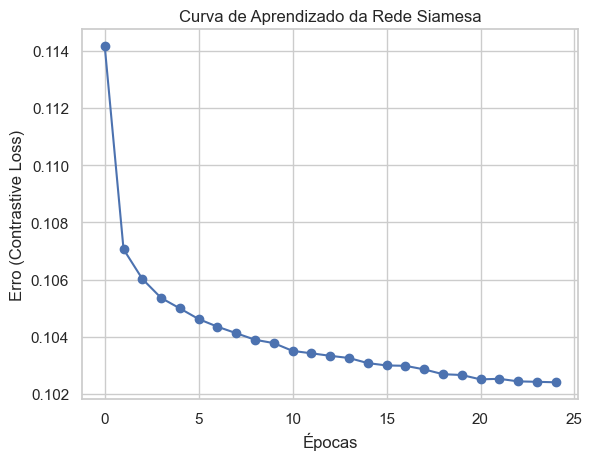

In [210]:
plt.plot(historico_loss, marker='o')
plt.title("Curva de Aprendizado da Rede Siamesa")
plt.xlabel("Épocas")
plt.ylabel("Erro (Contrastive Loss)")
plt.show()

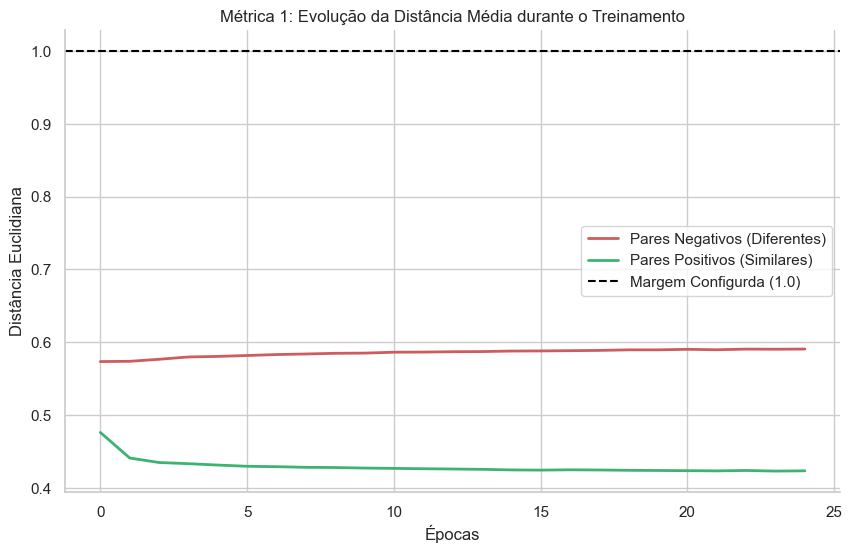

In [211]:
plt.figure(figsize=(10, 6))
plt.plot(historico_dist_diferentes, label='Pares Negativos (Diferentes)', color='indianred', linewidth=2)
plt.plot(historico_dist_similares, label='Pares Positivos (Similares)', color='mediumseagreen', linewidth=2)
# Linha de referência para mostrar onde está a margem
plt.axhline(y=MARGIN, color='black', linestyle='--', label=f'Margem Configurda ({MARGIN})')

plt.title('Métrica 1: Evolução da Distância Média durante o Treinamento')
plt.xlabel('Épocas')
plt.ylabel('Distância Euclidiana')
plt.legend()
sns.despine()
plt.show()

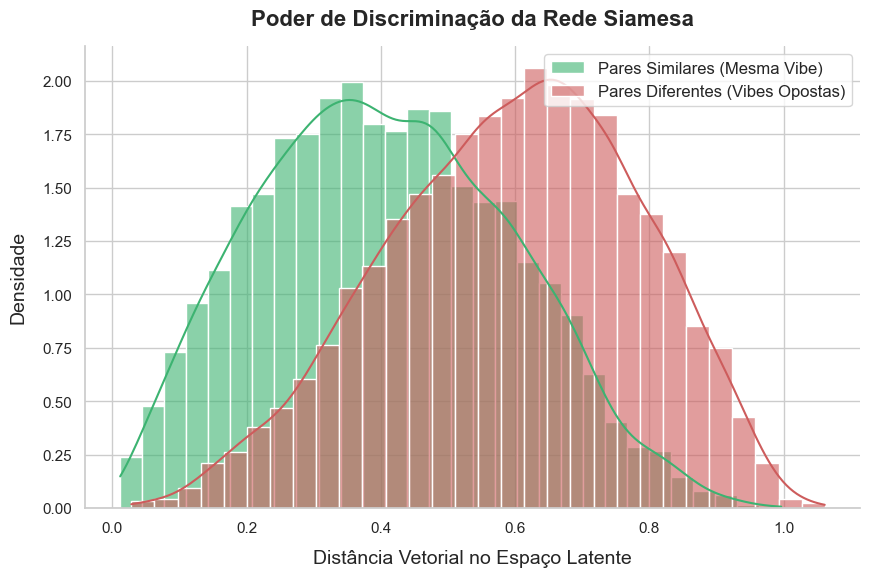

In [212]:
tensor_teste_X1 = torch.tensor(X1_teste, dtype=torch.float32)
tensor_teste_X2 = torch.tensor(X2_teste, dtype=torch.float32)

modelo.eval() # Garante que o modelo está em modo de avaliação
with torch.no_grad(): # Desliga o cálculo de gradientes para economizar memória e ficar super rápido
    embeddings_tensor_X1 = modelo.forward_once(tensor_teste_X1)
    embeddings_tensor_X2 = modelo.forward_once(tensor_teste_X2)

emb_X1_np = embeddings_tensor_X1.numpy()
emb_X2_np = embeddings_tensor_X2.numpy()

distancias = np.linalg.norm(emb_X1_np - emb_X2_np, axis=1)

distancias_similares = distancias[Y_teste == 1.0]
distancias_diferentes = distancias[Y_teste == 0.0]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plota a curva das músicas SIMILARES (em Verde)
sns.histplot(
    distancias_similares, 
    color="mediumseagreen", 
    label="Pares Similares (Mesma Vibe)", 
    kde=True,          # Adiciona a linha de contorno suave
    stat="density",    # Normaliza o gráfico
    alpha=0.6,         # Transparência
    bins=30
)

# Plota a curva das músicas DIFERENTES (em Vermelho)
sns.histplot(
    distancias_diferentes, 
    color="indianred", 
    label="Pares Diferentes (Vibes Opostas)", 
    kde=True, 
    stat="density", 
    alpha=0.6,
    bins=30
)

# Embelezamento do gráfico para a Apresentação
plt.title('Poder de Discriminação da Rede Siamesa', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Distância Vetorial no Espaço Latente', fontsize=14, labelpad=10)
plt.ylabel('Densidade', fontsize=14, labelpad=10)
plt.legend(fontsize=12, loc='upper right')

# Remove as bordas feias de cima e da direita
sns.despine()



# Mostra o gráfico na tela
plt.show()

## Construindo nosso buscador de recomendações

In [213]:
# 1. Pegar TODAS as features do dataframe escalonado
todas_as_features = df[colunas_features].astype(float).values

# 2. Converter a matriz inteira para um Tensor do PyTorch
tensor_todas_features = torch.tensor(todas_as_features, dtype=torch.float32)

# 3. Passar a matriz gigante pela rede para gerar os embeddings
modelo.eval() # Garante que o modelo está em modo de avaliação
with torch.no_grad(): # Desliga o cálculo de gradientes para economizar memória e ficar super rápido
    embeddings_tensor = modelo.forward_once(tensor_todas_features)

# 4. Converter o resultado para Numpy Array (O Scikit-learn precisa de Numpy, não Tensores)
embeddings_siamesa = embeddings_tensor.numpy()

print(f"Matriz de embeddings gerada! Formato: {embeddings_siamesa.shape}")
# O formato deve ser algo como (N, 32), onde N é o total de músicas únicas e 32 é o EMBEDDING_DIM

# 5. Inicializar e treinar o Buscador KNN
buscador = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
buscador.fit(embeddings_siamesa)
print("Buscador KNN treinado com os embeddings!")

Matriz de embeddings gerada! Formato: (81344, 32)
Buscador KNN treinado com os embeddings!


## Avaliando recomendações

### Recomendações puramente matemáticas

In [214]:
df.reset_index()
lista_track_positions = df.index.tolist()

In [220]:
# Música fixa da Taylor Swift
# indices_encontrados = df.index[df['track_id'] == '55n9yjI6qqXh5F2mYvUc2y'].tolist()
# id_musica_base = indices_encontrados[0]

# 1. Sorteia uma linha aleatória baseada no total de músicas que temos
linha_musica_base = random.randint(0, len(lista_track_positions) - 1)
id_musica_base = lista_track_positions[linha_musica_base]
vetor_musica_base = embeddings_siamesa[id_musica_base]

# 2. Busca os detalhes da música base (a que foi sorteada) para exibição
nome_base = df.loc[id_musica_base, 'track_name']
artista_base = df.loc[id_musica_base, 'artists']
genero_base = df.loc[id_musica_base, 'track_genre']

# 3. O buscador encontra os vizinhos mais próximos
distancias, indices = buscador.kneighbors([vetor_musica_base])

# --- EXIBIÇÃO DOS RESULTADOS ---
print("="*60)
print(f"MÚSICA SORTEADA (BASE):")
print(f"{nome_base} - {artista_base}")
print(f"Gênero original: {genero_base}")
print(f"Track ID: {id_musica_base}")
print("="*60)

# O índice 0 é a própria música, então iteramos a partir do índice 1
print("\nRECOMENDAÇÕES ENCONTRADAS:")
for i in range(1,6 ):
    linha_recomendada = indices[0][i]
    print(f"Linha recomenda: {linha_recomendada}")
    id_recomendado = lista_track_positions[linha_recomendada]
    distancia_calc = distancias[0][i]
    
    # Buscando o nome, artista e gênero da música recomendada
    nome = df.loc[id_recomendado, 'track_name']
    artista = df.loc[id_recomendado, 'artists']
    genero = df.loc[id_recomendado, 'track_genre']
    
    print(f"{i}º -> {nome} - {artista}")
    print(f"      Gênero: {genero} | Distância: {distancia_calc:.4f}\n")

MÚSICA SORTEADA (BASE):
Empathological Necroticism - Carcass
Gênero original: death-metal
Track ID: 19213

RECOMENDAÇÕES ENCONTRADAS:
Linha recomenda: 43283
1º -> Stratus - Lusine
      Gênero: idm | Distância: 0.0003

Linha recomenda: 34176
2º -> Incarnated Solvent Abuse - Carcass
      Gênero: grindcore | Distância: 0.0003

Linha recomenda: 34397
3º -> Anti-Christ Demon Core - ACxDC
      Gênero: grindcore | Distância: 0.0003

Linha recomenda: 34084
4º -> Pyosisified (Still Rotten to the Gore) - Carcass
      Gênero: grindcore | Distância: 0.0004

Linha recomenda: 35923
5º -> Mouths Of Babes - The Smashing Pumpkins
      Gênero: grunge | Distância: 0.0004



### Recomendações matemáticas com filtro de gênero

In [216]:
# Música fixa da Taylor Swift
# indices_encontrados = df.index[df['track_id'] == '55n9yjI6qqXh5F2mYvUc2y'].tolist()
# id_musica_base = indices_encontrados[0]

# 1. Sorteia uma linha aleatória baseada no total de músicas que temos
linha_musica_base = random.randint(0, len(lista_track_positions) - 1)
id_musica_base = lista_track_positions[linha_musica_base]
vetor_musica_base = embeddings_siamesa[id_musica_base]
print("Embedding:", vetor_musica_base[:5])
# 2. Busca os detalhes da música base (a que foi sorteada) para exibição
nome_base = df.loc[id_musica_base, 'track_name']
artista_base = df.loc[id_musica_base, 'artists']
genero_base = df.loc[id_musica_base, 'track_genre']

# 3. Encontra a posição (linha) de todas as músicas que possuem esse mesmo gênero
indices_mesmo_genero = [i for i, tid in enumerate(lista_track_positions) if df.loc[tid, 'track_genre'] == genero_base]

# 4. Filtra a matriz gigante para ter SÓ as músicas dessa bolha
embeddings_filtrados = embeddings_siamesa[indices_mesmo_genero]
lista_ids_filtrada = [lista_track_positions[i] for i in indices_mesmo_genero]

# 5. Cria e treina o buscador temporário instantaneamente
buscador_nicho = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
buscador_nicho.fit(embeddings_filtrados)

# 6. O buscador encontra os vizinhos mais próximos APENAS dentro do nicho
distancias, indices = buscador_nicho.kneighbors([vetor_musica_base])

# --- EXIBIÇÃO DOS RESULTADOS ---
print("="*60)
print(f"MÚSICA SORTEADA (BASE):")
print(f"{nome_base} - {artista_base}")
print(f"Gênero original: {genero_base}")
print(f"Track ID: {id_musica_base}")
print("="*60)

# O índice 0 é a própria música, então iteramos a partir do índice 1
print("\nRECOMENDAÇÕES ENCONTRADAS (SOMENTE MESMO GÊNERO):")
for i in range(1, 6):
    linha_recomendada = indices[0][i]
    
    id_recomendado = lista_ids_filtrada[linha_recomendada] 
    distancia_calc = distancias[0][i]
    
    # Buscando o nome, artista e gênero da música recomendada
    nome = df.loc[id_recomendado, 'track_name']
    artista = df.loc[id_recomendado, 'artists']
    genero = df.loc[id_recomendado, 'track_genre']
    
    print(f"{i}º -> {nome} - {artista}")
    print(f"      Gênero: {genero} | Distância: {distancia_calc:.4f}\n")

Embedding: [-0.16661678 -0.0494307  -0.1529193   0.17995924  0.19778408]
MÚSICA SORTEADA (BASE):
Roxinho - Vitor Fernandes;Tarcísio do Acordeon
Gênero original: forro
Track ID: 28267

RECOMENDAÇÕES ENCONTRADAS (SOMENTE MESMO GÊNERO):
1º -> Por Isso Bebo e Choro - Léo Magalhães
      Gênero: forro | Distância: 0.0018

2º -> Ranchinho (feat. Luan Estilizado) - Zé Cantor;Luan Estilizado
      Gênero: forro | Distância: 0.0020

3º -> Lisbela - Dominguinhos
      Gênero: forro | Distância: 0.0028

4º -> Some - Unha Pintada
      Gênero: forro | Distância: 0.0032

5º -> Lembrança De Um Beijo - Santanna "O Cantador"
      Gênero: forro | Distância: 0.0032



## Salvando nosso modelo treinado

In [217]:
salvar = False
if salvar:    
    lista_track_ids = df['track_id'].tolist()
    lista_generos = df['track_genre'].tolist()


    caminho_matriz_embeddings = '../backend/models/todos_os_embeddings.npy'
    caminho_lista_generos = '../backend/models/todos_os_generos.pkl'
    caminho_buscador = '../backend/models/buscador_knn.pkl'
    caminho_lista_track_ids = '../backend/models/lista_track_ids.pkl'
    caminho_siamesa = '../backend/models/rede_siamesa.pth'
    caminho_scaler_siamesa = '../backend/models/scaler_siamesa.pkl'

    joblib.dump(buscador, caminho_buscador)
    joblib.dump(lista_track_ids, caminho_lista_track_ids)
    torch.save(modelo.state_dict(), caminho_siamesa)
    np.save(caminho_matriz_embeddings, embeddings_siamesa)
    joblib.dump(lista_generos, caminho_lista_generos)
    joblib.dump(scaler, caminho_scaler_siamesa)

    print("Matriz de embeddings (.npy) e lista de gêneros (.pkl) salvas com sucesso!")
    print("Arquivos 'buscador_knn.pkl' e 'lista_track_ids.pkl' salvos com sucesso!")